<a href="https://colab.research.google.com/github/Podisti/KNN-bird-clasifier/blob/main/KNN_Bird_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =============================
# MODEL & RUN CONFIGURATION
# =============================

# 'True' to use pretrained model, which will be loaded from project files, 'False' to train a brand new model
USE_PRETRAINED = False

# 'True' to use ResNet50, 'False' to use smaller ResNet18
USE_RESNET50 = True


import os
import shutil
import random
import numpy as np
import random

In [4]:
# connection to one drive for the storing of weights during training
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# dataset download
import kagglehub
path = kagglehub.dataset_download("veeralakrishna/200-bird-species-with-11788-images")
print("Data ready at:", path)

100%|██████████| 1.11G/1.11G [00:13<00:00, 89.1MB/s]

Extracting files...


Data ready at: /root/.cache/kagglehub/datasets/veeralakrishna/200-bird-species-with-11788-images/versions/1


In [6]:
# dataset extraction
import tarfile

# source and destination directory
download_dir = path
extract_dir = '/content/CUB_200_dataset'
# create dst if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)
# files in the source
archives = ['CUB_200_2011.tgz', 'segmentations.tgz']

print(f"Starting extraction to: {extract_dir}\n")

# extraction
for archive_name in archives:
    archive_path = os.path.join(download_dir, archive_name)
    print(archive_path)

    # Check if the file actually exists before extracting
    if os.path.exists(archive_path):
        print(f"Extracting {archive_name}...")
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(path=extract_dir)
        print(f"Successfully extracted {archive_name}")
    else:
        print(f"Warning: Could not find {archive_name}")

print("\nExtraction completed")

extracted_path = extract_dir

Starting extraction to: /content/CUB_200_dataset

/root/.cache/kagglehub/datasets/veeralakrishna/200-bird-species-with-11788-images/versions/1/CUB_200_2011.tgz
Extracting CUB_200_2011.tgz...


/tmp/ipykernel_18023/1439880714.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Successfully extracted CUB_200_2011.tgz
/root/.cache/kagglehub/datasets/veeralakrishna/200-bird-species-with-11788-images/versions/1/segmentations.tgz
Extracting segmentations.tgz...
Successfully extracted segmentations.tgz

Extraction completed


In [7]:
# =============================
# ADD "NONE" CLASS TO DATASET
# =============================
base_path = os.path.join(extracted_path, "CUB_200_2011")

images_dir = os.path.join(base_path, "images")
classes_file = os.path.join(base_path, "classes.txt")
images_file = os.path.join(base_path, "images.txt")
labels_file = os.path.join(base_path, "image_class_labels.txt")
split_file = os.path.join(base_path, "train_test_split.txt")

NEW_CLASS_ID = 201
NEW_CLASS_NAME = "none"
NEW_CLASS_FOLDER = f"{NEW_CLASS_ID}.{NEW_CLASS_NAME}"

none_dir = os.path.join(images_dir, NEW_CLASS_FOLDER)
os.makedirs(none_dir, exist_ok=True)

print(f"Created folder: {none_dir}")

# =============================
# REGISTER NEW CLASS
# =============================
with open(classes_file, "r") as f:
    content = f.read()

if f"{NEW_CLASS_ID} {NEW_CLASS_NAME}" not in content:
    with open(classes_file, "a") as fa:
        fa.write(f"\n{NEW_CLASS_ID} {NEW_CLASS_NAME}")

# =============================
# GET NEXT IMAGE ID
# =============================
with open(images_file, "r") as f:
    lines = f.readlines()

next_id = int(lines[-1].split()[0]) + 1


# =============================
# DOWNLOAD INTEL DATASET
# =============================
intel_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Intel dataset at:", intel_path)

train_root = os.path.join(intel_path, "seg_train", "seg_train")

categories = [
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d))
]

print("Categories:", categories)


# =============================
# SAMPLE ~1000 IMAGES TOTAL
# =============================
TARGET_TOTAL = 1000
per_category = TARGET_TOTAL // len(categories)

copied_count = 0

for category in categories:
    category_path = os.path.join(train_root, category)

    images = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) == 0:
        continue

    sample = random.sample(images, min(per_category, len(images)))

    for img_name in sample:
        src = os.path.join(category_path, img_name)

        new_name = f"{category}_{img_name}"
        dst = os.path.join(none_dir, new_name)

        shutil.copy(src, dst)
        copied_count += 1

print(f"Copied {copied_count} images into 'none' class")


# =============================
# REGISTER NEW IMAGES
# =============================
existing_entries = set()

with open(images_file, "r") as f:
    for line in f:
        existing_entries.add(line.strip().split()[1])

image_files = [
    f for f in os.listdir(none_dir)
    if f"{NEW_CLASS_FOLDER}/{f}" not in existing_entries
]

with open(images_file, "a") as f_img, \
     open(labels_file, "a") as f_lbl, \
     open(split_file, "a") as f_split:

    for img_name in image_files:
        rel_path = f"{NEW_CLASS_FOLDER}/{img_name}"

        f_img.write(f"{next_id} {rel_path}\n")
        f_lbl.write(f"{next_id} {NEW_CLASS_ID}\n")

        is_train = 1 if random.random() < 0.8 else 0
        f_split.write(f"{next_id} {is_train}\n")

        next_id += 1

print("Finished adding 'none' class")

Created folder: /content/CUB_200_dataset/CUB_200_2011/images/201.none
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Intel dataset at: /kaggle/input/intel-image-classification
Categories: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Copied 996 images into 'none' class
Finished adding 'none' class


In [8]:
# dataset exploration
from PIL import Image

dataset_path = extracted_path
print(extracted_path)

image_extensions = {'.jpg', '.jpeg', '.png'}
classes = set()
total_images = 0
image_sizes = []

print("Exploring dataset...\n")

# go through all files
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if os.path.splitext(file)[1].lower() in image_extensions:
            total_images += 1

            # folders = bird names
            class_name = os.path.basename(root)
            classes.add(class_name)

            # sizes
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size)
            except Exception as e:
                pass

print(f"Total number of images: {total_images}")
print(f"Total number of categories: {len(classes)}")

print("\nClass names:", list(classes)[:5])

/content/CUB_200_dataset
Exploring dataset...

Total number of images: 24572
Total number of categories: 201

Class names: ['105.Whip_poor_Will', '156.White_eyed_Vireo', '041.Scissor_tailed_Flycatcher', '150.Sage_Thrasher', '151.Black_capped_Vireo']


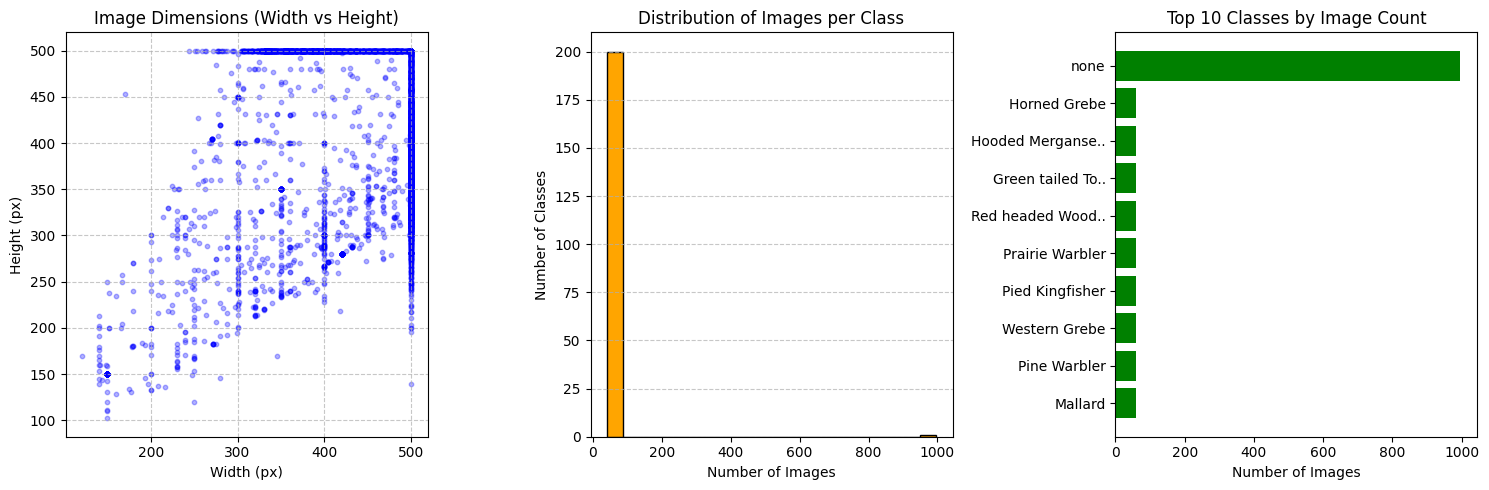

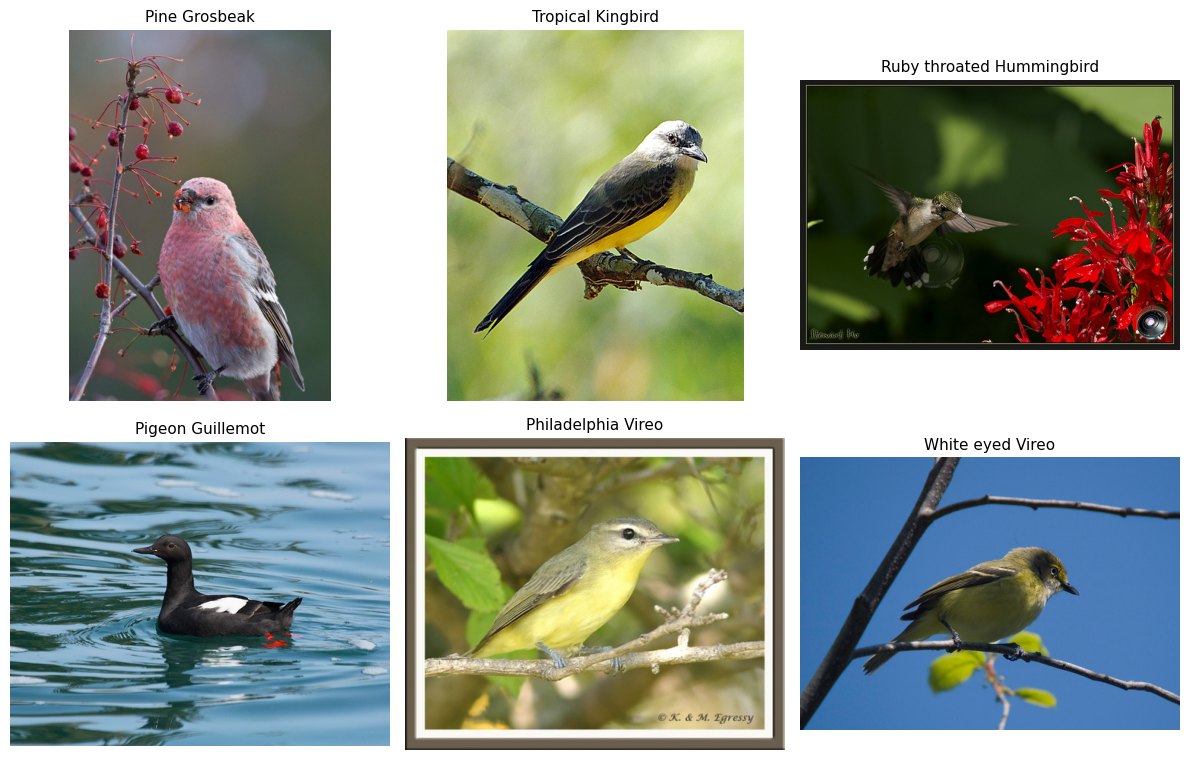

In [9]:
# data vizualization
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

data_path = '/content/CUB_200_dataset/CUB_200_2011/images'

image_extensions = {'.jpg', '.jpeg', '.png'}
image_sizes = []
class_counts = Counter()
all_image_paths = []


# gather image data
for root, dirs, files in os.walk(data_path):
    for file in files:
        if os.path.splitext(file)[1].lower() in image_extensions:
            img_path = os.path.join(root, file)
            all_image_paths.append(img_path)

            class_name = os.path.basename(root)
            # Clean up the name for readability
            clean_class_name = class_name.split('.')[-1].replace('_', ' ')
            class_counts[clean_class_name] += 1

            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size) # (width, height)
            except Exception:
                pass

widths, heights = zip(*image_sizes)

# ---------------------------------------------------------
# PLOT 1: Scatter plot of image dimensions
# ---------------------------------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(widths, heights, alpha=0.3, color='blue', s=10)
plt.title("Image Dimensions (Width vs Height)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.grid(True, linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# PLOT 2: Histogram of images per category
# ---------------------------------------------------------
plt.subplot(1, 3, 2)
# We expect this to be heavily clustered around ~60 images per class
plt.hist(class_counts.values(), bins=20, color='orange', edgecolor='black')
plt.title("Distribution of Images per Class")
plt.xlabel("Number of Images")
plt.ylabel("Number of Classes")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# PLOT 3: Bar chart of top 10 categories with most images
# ---------------------------------------------------------
plt.subplot(1, 3, 3)
top_10_classes = class_counts.most_common(10)
names, counts = zip(*top_10_classes)

# shorten names if needed
short_names = [n[:15] + '..' if len(n) > 15 else n for n in names]

plt.barh(short_names, counts, color='green')
plt.title("Top 10 Classes by Image Count")
plt.xlabel("Number of Images")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 4: Grid of random sample images
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# 6 random images
random_images = random.sample(all_image_paths, 6)

for i, img_path in enumerate(random_images):
    img = Image.open(img_path)

    raw_class = os.path.basename(os.path.dirname(img_path))
    display_name = raw_class.split('.')[-1].replace('_', ' ')

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(display_name, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:

import torch
from torchvision import datasets, transforms, models
from torchvision import tv_tensors

# =============================
# BOUNDING BOXES IN DICTIONARY
# =============================
print(base_path) # /content/CUB_200_dataset/CUB_200_2011

# connect image id to its relative path
image_id_to_relpath = {}
with open(os.path.join(base_path, "images.txt"), "r") as f:
    for line in f:
        img_id, rel_path = line.strip().split()
        image_id_to_relpath[img_id] = rel_path
# connect boundind box with the image relative path
bbox_dict = {}
with open(os.path.join(base_path, "bounding_boxes.txt"), "r") as f:
    for line in f:
        img_id, x, y, w, h = line.strip().split()
        rel_path = image_id_to_relpath[img_id]
        bbox_dict[rel_path] = [float(x), float(y), float(w), float(h)]

# ==============================
# WRAPPER FOR GETTING IMAGE DATA
# ==============================
class ImageFolder(datasets.ImageFolder):
    def __init__(self, root, bbox_dict, transform=None):
        super().__init__(root, transform=transform)
        self.bbox_dict = bbox_dict

    def __getitem__(self, index):
        # image data
        path, target = self.samples[index]
        image = self.loader(path)
        orig_w, orig_h = image.size
        # bbox
        folder_name = os.path.basename(os.path.dirname(path))
        file_name = os.path.basename(path)
        rel_path = f"{folder_name}/{file_name}"
        raw_bbox = self.bbox_dict.get(rel_path, [0.0, 0.0, 0.0, 0.0]) # for NONE class

        bbox_tv = tv_tensors.BoundingBoxes(
            raw_bbox,
            format=tv_tensors.BoundingBoxFormat.XYWH,
            canvas_size=(orig_h, orig_w)
        )
        # transform bbox as well
        if self.transform is not None:
            image, bbox_tv = self.transform(image, bbox_tv)
        # normalize bbox
        final_h, final_w = bbox_tv.canvas_size
        bbox_norm = bbox_tv / torch.tensor([final_w, final_h, final_w, final_h], dtype=torch.float32)

        return image, target, bbox_norm.squeeze()


/content/CUB_200_dataset/CUB_200_2011


In [11]:
# ==============================
# DATASET WRAPPER (WITH ATTRIBUTES)
# ==============================
from torch.utils.data import Dataset, DataLoader, random_split

class CUB200WithAttributes(Dataset):
    def __init__(self, image_folder_dataset, attributes_file_path, image_id_mapping_path):
        self.dataset = image_folder_dataset
        self.num_attributes = 312

        # 1. Map image_id onto file paths from images.txt
        self.image_id_to_path = {}
        self.path_to_image_id = {}
        with open(image_id_mapping_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    img_id = int(parts[0])
                    rel_path = parts[1]
                    self.image_id_to_path[img_id] = rel_path
                    self.path_to_image_id[rel_path] = img_id

        # 2. Create attribute map for every image_id
        self.attributes_map = {}
        print("Loading attributes...")
        with open(attributes_file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    img_id = int(parts[0])
                    attr_id = int(parts[1]) - 1
                    is_present = int(parts[2])

                    if img_id not in self.attributes_map:
                        self.attributes_map[img_id] = np.zeros(self.num_attributes, dtype=np.float32)

                    if is_present == 1:
                        self.attributes_map[img_id][attr_id] = 1.0

        print(f"Attributes loaded for {len(self.attributes_map)} images.")

        self.none_attributes = np.zeros(self.num_attributes, dtype=np.float32)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # 1. Load image and label
        img, label, bbox = self.dataset[idx]

        # 2. Get image path
        abs_path, _ = self.dataset.samples[idx]

        # 3. Search for attributes
        attributes = self.none_attributes
        path_parts = abs_path.split(os.sep)
        if len(path_parts) >= 2:
            rel_path_key = f"{path_parts[-2]}/{path_parts[-1]}"

            if rel_path_key in self.path_to_image_id:
                img_id = self.path_to_image_id[rel_path_key]
                if img_id in self.attributes_map:
                    attributes = self.attributes_map[img_id]
            else:
                # Return zeros for 'none' class
                pass

        return img, label, bbox, torch.from_numpy(attributes)

In [12]:
import torch.nn as nn
from torchvision.transforms import v2

# Augmentations definition
data_transforms = {
    'train': v2.Compose([
        v2.ToImage(),
        v2.RandomResizedCrop(224),
        v2.RandomHorizontalFlip(),
        v2.ColorJitter(brightness=0.2, contrast=0.2),
        v2.RandomRotation(15),
        v2.ClampBoundingBoxes(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': v2.Compose([
        v2.ToImage(),
        v2.Resize(256),
        v2.CenterCrop(224),
        v2.ClampBoundingBoxes(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
data_path = '/content/CUB_200_dataset/CUB_200_2011/images'

# Define two datasets with different transformation
train_dataset_full = ImageFolder(data_path, bbox_dict=bbox_dict, transform=data_transforms['train'])
val_dataset_full = ImageFolder(data_path, bbox_dict=bbox_dict, transform=data_transforms['val'])

# Paths to files with attributes
base_path = os.path.join(extracted_path, "CUB_200_2011")
attr_labels_file = os.path.join(base_path, "attributes", "image_attribute_labels.txt")
images_mapping_file = os.path.join(base_path, "images.txt")

# Wrap datasets - add attributes
train_dataset_attrs = CUB200WithAttributes(train_dataset_full, attr_labels_file, images_mapping_file)
val_dataset_attrs = CUB200WithAttributes(val_dataset_full, attr_labels_file, images_mapping_file)

# Create dividing indices
indices = torch.randperm(len(train_dataset_full)).tolist()
train_size = int(0.8 * len(train_dataset_full))

train_idx = indices[:train_size]
val_idx = indices[train_size:]

# Create subsets, every subset uses different transformations
train_data = torch.utils.data.Subset(train_dataset_attrs, train_idx)
val_data = torch.utils.data.Subset(val_dataset_attrs, val_idx)

# Apply to loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

Loading attributes...
Attributes loaded for 11788 images.
Loading attributes...
Attributes loaded for 11788 images.


In [13]:
# ==========================================
# MODEL SETUP & LOSS FUNCTIONS
# ==========================================
class BirdMultiTaskModel(nn.Module):
    def __init__(self, num_classes=201, num_attributes=312): # 200 - number of bird classes in dataset + 1 none
        super().__init__()

        # Use ResNet18 or ResNet50, based on choice in the first cell of the notebook
        if USE_RESNET50 == True:
          self.backbone = models.resnet50(weights='DEFAULT') # USE RESNET50
        else:
          self.backbone = models.resnet18(weights='IMAGENET1K_V1') # USE RESNET18

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # 1. HEAD - Classes
        self.fc_cls = nn.Linear(num_ftrs, num_classes)

        # 2. HEAD - BBox
        self.fc_bbox = nn.Sequential(nn.Linear(num_ftrs, 4), nn.Sigmoid())

        # 3. HEAD - Parts of the birds
        self.fc_attr = nn.Linear(num_ftrs, num_attributes)

    def forward(self, x):
        features = self.backbone(x)

        cls_out = self.fc_cls(features)
        bbox_out = self.fc_bbox(features)
        attr_out = self.fc_attr(features)

        # Return all 3 outputs
        return cls_out, bbox_out, attr_out

# Load pre-trained ResNet18
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ft = BirdMultiTaskModel(num_classes=201, num_attributes=312).to(device)

# ALL 3 LOSS FUNCTIONS (and optimization algorithm)
criterion_cls = nn.CrossEntropyLoss()
criterion_bbox = nn.MSELoss()
criterion_attr = nn.BCEWithLogitsLoss()

NONE_CLASS_ID = 200
optimizer = torch.optim.Adam(model_ft.parameters(), lr=0.001)

# DYNAMIC LR DECREASING: Every 5 epochs, reduce LR by one floating point
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


In [14]:
# Check whether GPU acceleration is available and set up
#   RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU -> SAVE
if not torch.cuda.is_available():
    print('GPU not found. Try:')
    print('  - RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU -> SAVE')
else:
    device_name = torch.cuda.get_device_name(0)
    print(f'Success! GPU: {device_name}')

# Print GPU details
!nvidia-smi

Success! GPU: Tesla T4
Fri May  8 16:51:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             26W /   70W |     223MiB /  15360MiB |      8%      Default |
|                                         |                        |                  N/A |
+------------------------

In [15]:
import time

if USE_PRETRAINED == False:
  def train_model(model, criterion_cls, criterion_bbox, criterion_attr, optimizer, scheduler, num_epochs=10):
      time_start = time.time()

      for epoch in range(num_epochs):
          print(f'Epoch {epoch + 1}/{num_epochs}')
          print('----------')

          # Every epoch consists of training and validation phases
          for phase in ['train', 'val']:
              if phase == 'train':
                  model.train()
                  dataloader = train_loader
                  dataset_size = len(train_data)
              else:
                  model.eval()
                  dataloader = val_loader
                  dataset_size = len(val_data)

              running_loss = 0.0
              running_bbox_loss = 0.0
              running_attr_loss = 0.0
              running_corrects = 0
              running_top5_corrects = 0
              running_birds_num = 0 # not counting NONE

              # Iterate over data
              for inputs, labels, bboxes, attributes in dataloader:
                  inputs = inputs.to(device)
                  labels = labels.to(device)
                  bboxes = bboxes.to(device).float()
                  attributes = attributes.to(device).float()

                  optimizer.zero_grad()

                  # Forward pass
                  with torch.set_grad_enabled(phase == 'train'):
                      outputs_cls, outputs_bbox, outputs_attr = model(inputs)
                      _, preds = torch.max(outputs_cls, 1)
                      # classification loss
                      loss_cls = criterion_cls(outputs_cls, labels)
                      # bbox loss
                      bird_mask = (labels != NONE_CLASS_ID)
                      birds_in_batch = bird_mask.sum().item()
                      if birds_in_batch > 0:
                          loss_bbox = criterion_bbox(outputs_bbox[bird_mask], bboxes[bird_mask])
                          loss_attr = criterion_attr(outputs_attr[bird_mask], attributes[bird_mask])
                      else:
                          loss_bbox = torch.tensor(0.0, device=device)
                          loss_attr = torch.tensor(0.0, device=device)

                      # total loss
                      loss = (1.0 * loss_cls) + (1.0 * loss_bbox) + (1.0 * loss_attr)

                      _, top5_preds = outputs_cls.topk(5, 1)
                      running_top5_corrects += (top5_preds == labels.view(-1, 1)).sum().item()

                      # Backward pass + optimization (only in training phase)
                      if phase == 'train':
                          loss.backward()
                          optimizer.step()

                  running_loss += loss.item() * inputs.size(0)
                  running_bbox_loss += loss_bbox.item() * birds_in_batch
                  running_attr_loss += loss_attr.item() * birds_in_batch
                  running_corrects += torch.sum(preds == labels.data)
                  running_birds_num += birds_in_batch

              # Decrease learning rate if condition satisfied
              if phase == 'train':
                  scheduler.step()

              epoch_loss = running_loss / dataset_size
              epoch_bbox_loss = running_bbox_loss / running_birds_num if running_birds_num > 0 else 0.0
              epoch_attr_loss = running_attr_loss / running_birds_num if running_birds_num > 0 else 0.0
              epoch_acc = running_corrects.double() / dataset_size
              epoch_top5_acc = running_top5_corrects / dataset_size


              print(f'{phase}')
              print(f'  Class Loss: {epoch_loss:.4f} | BBox MSE: {epoch_bbox_loss:.4f} | Attr: {epoch_attr_loss:.4f}')
              print(f'  Accuracy:   {epoch_acc:.4f} | Acc-Top5: {epoch_top5_acc:.4f}')

          print()

      time_elapsed = time.time() - time_start
      print(f'Training finished in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
      return model

  # Run 5 epochs
  model_ft = train_model(
      model_ft,
      criterion_cls,
      criterion_bbox,
      criterion_attr,
      optimizer,
      exp_lr_scheduler,
      num_epochs=15
  )

Epoch 1/15
----------
train
  Class Loss: 4.0076 | BBox MSE: 0.0350 | Attr: 0.2511
  Accuracy:   0.1956 | Acc-Top5: 0.3973
val
  Class Loss: 3.0821 | BBox MSE: 0.0287 | Attr: 0.2345
  Accuracy:   0.3039 | Acc-Top5: 0.6175

Epoch 2/15
----------
train
  Class Loss: 2.7360 | BBox MSE: 0.0271 | Attr: 0.2257
  Accuracy:   0.3926 | Acc-Top5: 0.6740
val
  Class Loss: 2.5185 | BBox MSE: 0.0205 | Attr: 0.2241
  Accuracy:   0.4451 | Acc-Top5: 0.7497

Epoch 3/15
----------
train
  Class Loss: 2.2352 | BBox MSE: 0.0246 | Attr: 0.2205
  Accuracy:   0.4955 | Acc-Top5: 0.7687
val
  Class Loss: 1.8844 | BBox MSE: 0.0165 | Attr: 0.2181
  Accuracy:   0.5620 | Acc-Top5: 0.8440

Epoch 4/15
----------
train
  Class Loss: 1.9541 | BBox MSE: 0.0226 | Attr: 0.2176
  Accuracy:   0.5652 | Acc-Top5: 0.8129
val
  Class Loss: 1.6069 | BBox MSE: 0.0135 | Attr: 0.2140
  Accuracy:   0.6339 | Acc-Top5: 0.8819

Epoch 5/15
----------
train
  Class Loss: 1.7827 | BBox MSE: 0.0212 | Attr: 0.2147
  Accuracy:   0.6039 | Ac

In [16]:
# Load or save model, based on choice in the first cell of the notebook
if USE_PRETRAINED == True:
  # Load pretrained model
  if USE_RESNET50 == True:
    model_ft.load_state_dict(torch.load("/content/drive/MyDrive/bird_resnet50.pth", map_location=device))
    model_ft.eval()
  else:
    model_ft.load_state_dict(torch.load("/content/drive/MyDrive/bird_resnet18.pth", map_location=device))
    model_ft.eval()
else:
  # Save model
  if USE_RESNET50 == True:
    torch.save(model_ft.state_dict(), "/content/drive/MyDrive/bird_resnet50.pth")
  else:
    torch.save(model_ft.state_dict(), "/content/drive/MyDrive/bird_resnet18.pth")


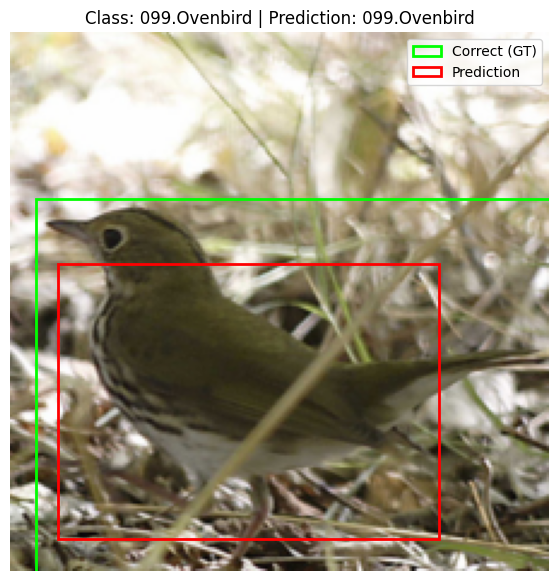

In [17]:
# ==========================================
# BBOX VISUALIZE
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_random_bbox(model, dataset, device):
    model.eval()
    NONE_CLASS_ID = 200

    # random pick
    while True:
        idx = random.randint(0, len(dataset) - 1)
        img_tensor, label, true_bbox_norm, attributes = dataset[idx]
        if label != NONE_CLASS_ID:
            break
    # use model
    with torch.no_grad():
        img_input = img_tensor.unsqueeze(0).to(device)
        cls_preds, bbox_preds, attr_preds = model(img_input)

        _, pred_label = torch.max(cls_preds, 1)
        pred_bbox_norm = bbox_preds[0].cpu()

    # get names
    class_names = dataset.dataset.dataset.classes
    true_name = class_names[label]
    pred_name = class_names[pred_label.item()]

    # visualize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_display = img_tensor.cpu() * std + mean
    img_display = torch.clamp(img_display, 0, 1).permute(1, 2, 0).numpy()
    _, h, w = img_tensor.shape
    # get coordinates
    true_x, true_y, true_w, true_h = (true_bbox_norm * torch.tensor([w, h, w, h])).numpy()
    pred_x, pred_y, pred_w, pred_h = (pred_bbox_norm * torch.tensor([w, h, w, h])).numpy()
    fig, ax = plt.subplots(1, figsize=(7, 7))
    ax.imshow(img_display)
    # Correct - green
    rect_true = patches.Rectangle((true_x, true_y), true_w, true_h,
                                  linewidth=2, edgecolor='lime', facecolor='none', label='Correct (GT)')
    ax.add_patch(rect_true)
    # Predicted - red
    rect_pred = patches.Rectangle((pred_x, pred_y), pred_w, pred_h,
                                  linewidth=2, edgecolor='red', facecolor='none', label='Prediction')
    ax.add_patch(rect_pred)

    plt.title(f"Class: {true_name} | Prediction: {pred_name}")
    plt.legend()
    plt.axis('off')
    plt.show()

visualize_random_bbox(model_ft, val_data, device)

In [18]:
# ==========================================
# EXTENDED EVALUATION SCRIPT
# ==========================================
#
# Added:
#   1. Per-class accuracy
#   2. Most confused class pairs
#   3. IoU@0.5 and IoU@0.75
#   4. Confidence / calibration analysis
#   5. Train vs validation metrics placeholders
#
# ==========================================

from datetime import datetime
from collections import defaultdict

import torch.nn.functional as F


from torchvision import models

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIG
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/bird_resnet18.pth"

TOP_K = 5
NONE_CLASS_ID = 200
NUM_CLASSES = 201

RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

RESULTS_FILE = os.path.join(
    RESULTS_DIR,
    f"evaluation_{timestamp}.txt"
)

CONF_MATRIX_IMG = os.path.join(
    RESULTS_DIR,
    f"confusion_matrix_{timestamp}.png"
)

CONFIDENCE_HIST_IMG = os.path.join(
    RESULTS_DIR,
    f"confidence_histogram_{timestamp}.png"
)

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

# ==========================================
# MODEL
# ==========================================

class BirdMultiTaskModel(nn.Module):

    def __init__(self, num_classes=201, num_attributes=312):
        super().__init__()

        self.backbone = models.resnet18(weights=None)

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.fc_cls = nn.Linear(num_ftrs, num_classes)

        self.fc_bbox = nn.Sequential(
            nn.Linear(num_ftrs, 4),
            nn.Sigmoid()
        )

        self.fc_attr = nn.Linear(num_ftrs, num_attributes)

    def forward(self, x):

        features = self.backbone(x)

        cls_out = self.fc_cls(features)
        bbox_out = self.fc_bbox(features)
        attr_out = self.fc_attr(features)

        return cls_out, bbox_out, attr_out


# ==========================================
# LOAD MODEL
# ==========================================

model = BirdMultiTaskModel(num_classes=NUM_CLASSES, num_attributes=312)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

model = model.to(device)
model.eval()

class_names = val_dataset_full.classes

print("Model loaded successfully.")

# ==========================================
# IoU
# ==========================================

def bbox_iou(box1, box2):

    x1_min = box1[0]
    y1_min = box1[1]
    x1_max = box1[0] + box1[2]
    y1_max = box1[1] + box1[3]

    x2_min = box2[0]
    y2_min = box2[1]
    x2_max = box2[0] + box2[2]
    y2_max = box2[1] + box2[3]

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w = max(0, inter_xmax - inter_xmin)
    inter_h = max(0, inter_ymax - inter_ymin)

    intersection = inter_w * inter_h

    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)

    union = area1 + area2 - intersection

    if union == 0:
        return 0.0

    return intersection / union


# ==========================================
# METRIC STORAGE
# ==========================================

all_labels = []
all_preds = []

all_attr_labels = []
all_attr_preds = []

all_confidences = []
all_correctness = []

iou_scores = []

correct_top1 = 0
correct_topk = 0

total_samples = 0

class_names = val_loader.dataset.dataset.dataset.classes

# ==========================================
# EVALUATION
# ==========================================

with torch.no_grad():

    for inputs, labels, bboxes, attributes in val_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)
        bboxes = bboxes.to(device)
        attributes = attributes.to(device).float()

        outputs_cls, outputs_bbox, outputs_attr = model(inputs)

        # ======================================
        # SOFTMAX CONFIDENCE
        # ======================================

        probs = F.softmax(outputs_cls, dim=1)

        confidences, preds = torch.max(probs, 1)

        attr_probs = torch.sigmoid(outputs_attr)
        attr_preds_bin = (attr_probs > 0.5).float()

        # ======================================
        # TOP-1
        # ======================================

        correct_top1 += torch.sum(
            preds == labels
        ).item()

        # ======================================
        # TOP-K
        # ======================================

        _, topk_preds = outputs_cls.topk(TOP_K, 1)

        correct_topk += (
            topk_preds == labels.view(-1, 1)
        ).sum().item()

        # ======================================
        # STORE
        # ======================================

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

        all_confidences.extend(
            confidences.cpu().numpy()
        )

        all_attr_labels.append(attributes.cpu().numpy())
        all_attr_preds.append(attr_preds_bin.cpu().numpy())

        correctness = (
            preds == labels
        ).cpu().numpy()

        all_correctness.extend(correctness)

        # ======================================
        # IoU
        # ======================================

        for i in range(len(labels)):

            if labels[i].item() == NONE_CLASS_ID:
                continue

            gt_box = bboxes[i].cpu().numpy()
            pred_box = outputs_bbox[i].cpu().numpy()

            iou = bbox_iou(gt_box, pred_box)

            iou_scores.append(iou)

        total_samples += labels.size(0)

all_attr_labels_np = np.concatenate(all_attr_labels)
all_attr_preds_np = np.concatenate(all_attr_preds)
attr_accuracy = (all_attr_labels_np == all_attr_preds_np).mean()
print(f"Attribute Prediction Accuracy: {attr_accuracy:.4f}")

# ==========================================
# MAIN METRICS
# ==========================================

top1_acc = correct_top1 / total_samples
topk_acc = correct_topk / total_samples

mean_iou = np.mean(iou_scores)

# ==========================================
# IoU THRESHOLDS
# ==========================================

iou_scores_np = np.array(iou_scores)

iou_50 = np.mean(iou_scores_np >= 0.5)
iou_75 = np.mean(iou_scores_np >= 0.75)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(all_labels, all_preds)

# ==========================================
# PER-CLASS ACCURACY
# ==========================================

per_class_accuracy = {}

for class_id in range(NUM_CLASSES):

    total_class_samples = cm[class_id].sum()

    if total_class_samples == 0:
        continue

    correct_predictions = cm[class_id, class_id]

    acc = correct_predictions / total_class_samples

    per_class_accuracy[class_id] = acc

# ==========================================
# BEST / WORST CLASSES
# ==========================================

sorted_classes = sorted(
    per_class_accuracy.items(),
    key=lambda x: x[1],
    reverse=True
)

best_classes = sorted_classes[:10]
worst_classes = sorted_classes[-10:]

# ==========================================
# MOST CONFUSED CLASS PAIRS
# ==========================================

confusions = []

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        if i == j:
            continue

        confusion_count = cm[i, j]

        if confusion_count > 0:
            confusions.append(
                (i, j, confusion_count)
            )

confusions = sorted(
    confusions,
    key=lambda x: x[2],
    reverse=True
)

top_confusions = confusions[:20]

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

report = classification_report(
    all_labels,
    all_preds,
    digits=4,
    zero_division=0
)

# ==========================================
# CONFIDENCE ANALYSIS
# ==========================================

avg_confidence = np.mean(all_confidences)

correct_confidences = [
    c for c, ok in zip(all_confidences, all_correctness)
    if ok
]

wrong_confidences = [
    c for c, ok in zip(all_confidences, all_correctness)
    if not ok
]

avg_correct_conf = np.mean(correct_confidences)
avg_wrong_conf = np.mean(wrong_confidences)

# ==========================================
# CONFIDENCE HISTOGRAM
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    correct_confidences,
    bins=20,
    alpha=0.7,
    label="Correct Predictions"
)

plt.hist(
    wrong_confidences,
    bins=20,
    alpha=0.7,
    label="Wrong Predictions"
)

plt.xlabel("Confidence")
plt.ylabel("Count")

plt.title("Prediction Confidence Histogram")

plt.legend()

plt.tight_layout()

plt.savefig(
    CONFIDENCE_HIST_IMG,
    dpi=300
)

plt.close()

# ==========================================
# CONFUSION MATRIX FIGURE
# ==========================================

cm_normalized = cm.astype("float") / (
    cm.sum(axis=1)[:, np.newaxis] + 1e-8
)

plt.figure(figsize=(24, 24))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False,
    square=True
)

plt.title("Normalized Confusion Matrix")

plt.tight_layout()

plt.savefig(
    CONF_MATRIX_IMG,
    dpi=300
)

plt.close()

# ==========================================
# SAVE RESULTS
# ==========================================

with open(RESULTS_FILE, "w") as f:

    f.write("=====================================\n")
    f.write("EXTENDED EVALUATION RESULTS\n")
    f.write("=====================================\n\n")

    f.write(f"Timestamp: {timestamp}\n\n")

    # ======================================
    # MODEL
    # ======================================

    f.write("=====================================\n")
    f.write("MODEL ARCHITECTURE\n")
    f.write("=====================================\n\n")

    f.write(str(model))
    f.write("\n\n")

    # ======================================
    # METRICS
    # ======================================

    f.write("=====================================\n")
    f.write("MAIN METRICS\n")
    f.write("=====================================\n\n")

    f.write(f"Top-1 Accuracy: {top1_acc:.6f}\n")
    f.write(f"Top-{TOP_K} Accuracy: {topk_acc:.6f}\n")

    f.write(f"Attribute Accuracy (Parts): {attr_accuracy:.6f}\n")

    f.write(f"Mean IoU: {mean_iou:.6f}\n")
    f.write(f"IoU@0.50: {iou_50:.6f}\n")
    f.write(f"IoU@0.75: {iou_75:.6f}\n\n")

    # ======================================
    # CONFIDENCE
    # ======================================

    f.write("=====================================\n")
    f.write("CONFIDENCE ANALYSIS\n")
    f.write("=====================================\n\n")

    f.write(f"Average Confidence: {avg_confidence:.6f}\n")
    f.write(f"Average Correct Confidence: {avg_correct_conf:.6f}\n")
    f.write(f"Average Wrong Confidence: {avg_wrong_conf:.6f}\n\n")

    # ======================================
    # BEST CLASSES
    # ======================================

    f.write("=====================================\n")
    f.write("BEST PERFORMING CLASSES\n")
    f.write("=====================================\n\n")

    for cls_id, acc in best_classes:

        class_name = class_names[cls_id]

        f.write(
            f"[{cls_id}] {class_name}: "
            f"{acc:.6f}\n"
        )

    f.write("\n")

    # ======================================
    # WORST CLASSES
    # ======================================

    f.write("=====================================\n")
    f.write("WORST PERFORMING CLASSES\n")
    f.write("=====================================\n\n")

    for cls_id, acc in worst_classes:
        class_name = class_names[cls_id]

        f.write(
            f"[{cls_id}] {class_name}: "
            f"{acc:.6f}\n"
        )

    f.write("\n")

    # ======================================
    # CONFUSED CLASSES
    # ======================================

    f.write("=====================================\n")
    f.write("MOST CONFUSED CLASS PAIRS\n")
    f.write("=====================================\n\n")

    for gt, pred, count in top_confusions:

        gt_name = class_names[gt]
        pred_name = class_names[pred]

        f.write(
            f"[{gt}] {gt_name} "
            f"-> "
            f"[{pred}] {pred_name} "
            f": {count} times\n"
        )

    f.write("\n")

    # ======================================
    # FULL REPORT
    # ======================================

    f.write("=====================================\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("=====================================\n\n")

    f.write(report)

# ==========================================
# DONE
# ==========================================

print("\n=====================================")
print("Evaluation complete.")
print("=====================================")

print(f"\nResults:")
print(f"  {RESULTS_FILE}")

print(f"\nConfusion Matrix:")
print(f"  {CONF_MATRIX_IMG}")

print(f"\nConfidence Histogram:")
print(f"  {CONFIDENCE_HIST_IMG}")

Model loaded successfully.
Attribute Prediction Accuracy: 0.9237

Evaluation complete.

Results:
  results/evaluation_20260508_172438.txt

Confusion Matrix:
  results/confusion_matrix_20260508_172438.png

Confidence Histogram:
  results/confidence_histogram_20260508_172438.png


In [26]:
# ==========================================
# CREATE A DICTIONARY OF BIRDS' PARTS & WEIGHTS
# ==========================================
import pandas as pd

print("Creating a bird parts dictionary...")

# Paths
base_path = os.path.join(extracted_path, "CUB_200_2011")
attr_labels_file = os.path.join(base_path, "attributes", "image_attribute_labels.txt")
image_class_labels_file = os.path.join(base_path, "image_class_labels.txt")
attr_names_file = os.path.join(extracted_path, "attributes.txt")

# Load attribute dictionary for human-readable output
attribute_names_list = []
if os.path.exists(attr_names_file):
    with open(attr_names_file, 'r') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) == 2:
                attribute_names_list.append(parts[1])
else:
    print(f"Warning: File {attr_names_file} not found.")

# Load data using Pandas library
attr_data = pd.read_csv(
    attr_labels_file,
    sep=r'\s+',
    header=None,
    names=['img_id', 'attr_id', 'is_present', 'certainty', 'time'],
    engine='python',
    on_bad_lines='skip'
)

img_classes = pd.read_csv(
    image_class_labels_file,
    sep=r'\s+',
    header=None,
    names=['img_id', 'class_id'],
    engine='python',
    on_bad_lines='skip'
)

# Create dictionary using mean aggregation
merged = pd.merge(attr_data, img_classes, on='img_id')
attribute_dictionary = merged.groupby(['class_id', 'attr_id'])['is_present'].mean().unstack().fillna(0)
attribute_dict_tensor = torch.tensor(attribute_dictionary.values).to(device).float()

print(f"Dictionary created. Shape: {attribute_dict_tensor.shape}")

# ==========================================
# WEIGHS (TF-IDF PENALIZATION)
# ==========================================
class_presence = (attribute_dict_tensor > 0.1).sum(dim=0).float()
weights_tensor = torch.log(200.0 / (class_presence + 1.0))

# Normalize weighs into 0-1
weights_tensor = (weights_tensor - weights_tensor.min()) / (weights_tensor.max() - weights_tensor.min())
weights_tensor = weights_tensor.to(device)

print(f"TF-IDF Weights created. Shape: {weights_tensor.shape}")

Creating a bird parts dictionary...
Dictionary created. Shape: torch.Size([200, 312])
TF-IDF Weights created. Shape: torch.Size([312])


In [27]:
if USE_PRETRAINED == False:
  # ==========================================
  # CALCULATE TF-IDF WEIGHTS
  # ==========================================
  print("Calculating expert TF-IDF weights for attributes...")

  # Calculate class presence for each attribute
  class_presence = (attribute_dict_tensor > 0.1).sum(dim=0).float()
  weights_tensor = torch.log(200.0 / (class_presence + 1.0))

  # Normalize weights to [0, 1] range
  weights_tensor = (weights_tensor - weights_tensor.min()) / (weights_tensor.max() - weights_tensor.min())
  weights_tensor = weights_tensor.to(device)


  # ==========================================
  # SMART CLASSIFICATION: TOP-K TIE-BREAKER
  # ==========================================
  def classify_with_logic(model, img_tensor, attribute_dict, weights, device, alpha_high=0.5, alpha_low=0.0, conf_threshold=0.65, T=0.02):
      model.eval()
      with torch.no_grad():
          img_input = img_tensor.unsqueeze(0).to(device)
          cls_out, bbox_out, attr_out = model(img_input)

          # 1. Visual prediction
          visual_probs = torch.softmax(cls_out, dim=1)[0][:200]
          visual_pred_idx = torch.argmax(visual_probs).item()
          visual_conf = visual_probs[visual_pred_idx].item()

          # 2. Logical prediction (Attributes)
          predicted_attr_probs = torch.sigmoid(attr_out)[0] * weights
          semantic_scores = F.cosine_similarity(predicted_attr_probs.unsqueeze(0), attribute_dict)
          semantic_probs = torch.softmax(semantic_scores / T, dim=0)

          # 3. Top-K Masking (Tie-Breaker logic)
          if visual_conf >= conf_threshold:
              # Scenario 1: High visual confidence, disable logic
              final_probs = visual_probs
              final_pred_idx = visual_pred_idx
              final_conf = visual_conf
              used_alpha = alpha_low
          else:
              # Scenario 2: Low visual confidence, apply tie-breaker
              used_alpha = alpha_high
              TOP_K = 3

              # Find Top-K visual predictions
              _, top_k_indices = torch.topk(visual_probs, TOP_K)

              # Create a mask to filter out non-Top-K classes
              mask = torch.zeros_like(visual_probs)
              mask[top_k_indices] = 1.0

              # Combine probabilities and apply the mask
              combined_probs = ((1 - used_alpha) * visual_probs + used_alpha * semantic_probs) * mask

              final_pred_idx = torch.argmax(combined_probs).item()
              final_conf = combined_probs[final_pred_idx].item()

          return {
              'visual_pred': visual_pred_idx,
              'visual_conf': visual_conf,
              'final_pred': final_pred_idx,
              'final_conf': final_conf,
              'attr_probs': predicted_attr_probs.cpu().numpy(),
              'used_alpha': used_alpha
          }


  # ==========================================
  # EVALUATION FUNCTION
  # ==========================================
  def evaluate_logic_impact(model, val_loader, attribute_dict, weights, device, alpha_high=0.5, alpha_low=0.0, conf_threshold=0.65, T=0.02, num_samples=500):
      model.eval()
      stats = {
          'total': 0,
          'visual_correct': 0,
          'logic_correct': 0,
          'logic_fixed_it': 0,
          'logic_broke_it': 0,
          'both_correct': 0,
          'both_wrong': 0,
          'conf_increased': 0,
          'conf_decreased': 0
      }

      print(f"\nEvaluating {num_samples} images (Smart Alpha, Threshold={conf_threshold:.2f}, T={T})...")

      processed = 0
      with torch.no_grad():
          for imgs, labels, _, _ in val_loader:
              if processed >= num_samples: break

              for i in range(len(imgs)):
                  if processed >= num_samples: break

                  img_t = imgs[i]
                  true_label = labels[i].item()

                  # Ignore 'None' class
                  if true_label >= 200: continue

                  # Run smart classification
                  res = classify_with_logic(model, img_t, attribute_dict, weights, device,
                                            alpha_high=alpha_high, alpha_low=alpha_low,
                                            conf_threshold=conf_threshold, T=T)

                  v_pred = res['visual_pred']
                  l_pred = res['final_pred']
                  v_conf = res['visual_conf']
                  l_conf = res['final_conf']

                  stats['total'] += 1

                  # Analyze accuracy
                  is_v_correct = (v_pred == true_label)
                  is_l_correct = (l_pred == true_label)

                  if is_v_correct: stats['visual_correct'] += 1
                  if is_l_correct: stats['logic_correct'] += 1

                  if not is_v_correct and is_l_correct:
                      stats['logic_fixed_it'] += 1
                  elif is_v_correct and not is_l_correct:
                      stats['logic_broke_it'] += 1
                  elif is_v_correct and is_l_correct:
                      stats['both_correct'] += 1
                      # Track confidence changes
                      if l_conf > v_conf: stats['conf_increased'] += 1
                      elif l_conf < v_conf: stats['conf_decreased'] += 1
                  else:
                      stats['both_wrong'] += 1

                  processed += 1

      # Print results
      print("\n" + "="*45)
      print("SMART LOGIC (DYNAMIC ALPHA) IMPACT STATS")
      print("="*45)
      print(f"Total processed:                       {stats['total']}")
      print(f"Original Accuracy (visual only):       {stats['visual_correct']/stats['total']:.2%}")
      print(f"New Accuracy (after logic):            {stats['logic_correct']/stats['total']:.2%}")
      print("-" * 45)
      print(f"FIXED by logic:       {stats['logic_fixed_it']}")
      print(f"BROKEN by logic:      {stats['logic_broke_it']}")
      print(f"Both correct:         {stats['both_correct']}")
      print(f"Both wrong:           {stats['both_wrong']}")
      print("-" * 45)
      if stats['both_correct'] > 0:
          print(f"Confidence increased: {stats['conf_increased']}")
          print(f"Confidence decreased: {stats['conf_decreased']}")
      print("="*45)


  # ==========================================
  # RUN EVALUATION
  # ==========================================
  evaluate_logic_impact(model_ft, val_loader, attribute_dict_tensor, weights_tensor, device,
                        alpha_high=0.5, alpha_low=0.0, conf_threshold=0.65, T=0.02, num_samples=500)
else:
  print("Evaluation with logic was skipped, because pre-trained model was used.")
  print("Pre-trained model has been trained on a random data split, which is not known in this session.")
  print("Therefore, data leakage is very probably going to occur.")

Calculating expert TF-IDF weights for attributes...

Evaluating 500 images (Smart Alpha, Threshold=0.65, T=0.02)...

SMART LOGIC (DYNAMIC ALPHA) IMPACT STATS
Total processed:                       500
Original Accuracy (visual only):       80.20%
New Accuracy (after logic):            79.40%
---------------------------------------------
FIXED by logic:       7
BROKEN by logic:      11
Both correct:         390
Both wrong:           92
---------------------------------------------
Confidence increased: 7
Confidence decreased: 30


In [21]:
########################################################################################################################################
########################################################################################################################################
########################################################################################################################################